# Brazilian E-Commerce Analysis

![alt text](https://i.imgur.com/HRhd2Y0.png)

## Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

In [3]:
olist_sellers_dataset = pd.read_csv("olist_sellers_dataset.csv")
product_category_name_translation = pd.read_csv("product_category_name_translation.csv")
olist_orders_dataset = pd.read_csv("olist_orders_dataset.csv")
olist_order_items_dataset = pd.read_csv("olist_order_items_dataset.csv")
olist_customers_dataset = pd.read_csv("olist_customers_dataset.csv")
olist_geolocation_dataset = pd.read_csv("olist_geolocation_dataset.csv")
olist_order_payments_dataset = pd.read_csv("olist_order_payments_dataset.csv")
olist_order_reviews_dataset = pd.read_csv("olist_order_reviews_dataset.csv")
olist_products_dataset = pd.read_csv("olist_products_dataset.csv")

In [4]:

df = olist_orders_dataset.copy()

#  Orders + Customers
df = df.merge(
    olist_customers_dataset,
    on="customer_id",
    how="left"
)

# df + Order Items
df = df.merge(
    olist_order_items_dataset,
    on="order_id",
    how="left"
)

# df + Products
df = df.merge(
    olist_products_dataset,
    on="product_id",
    how="left"
)

# df + Sellers
df = df.merge(
    olist_sellers_dataset,
    on="seller_id",
    how="left"
)

# df  + Payments
df = df.merge(
    olist_order_payments_dataset,
    on="order_id",
    how="left"
)

# df + Reviews
df = df.merge(
    olist_order_reviews_dataset,
    on="order_id",
    how="left"
)

# df + Product Category Translation
df = df.merge(
    product_category_name_translation,
    on="product_category_name",
    how="left"
)

# 8. Handle Geolocation
geo = olist_geolocation_dataset.groupby("geolocation_zip_code_prefix").agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"
}).reset_index()

# Merge geolocation
df = df.merge(
    geo,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,3149.0,-23.576983,-46.587161
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,3149.0,-23.576983,-46.587161
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,3149.0,-23.576983,-46.587161
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,47813.0,-12.177924,-44.660711
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,75265.0,-16.745150,-48.514783


## Data Shape


In [5]:
print("Shape:", df.shape)

Shape: (119143, 43)


In [6]:
print("\nColumn names:")
print(df.columns.tolist())



Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'product_category_name_english', 'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']


In [7]:
print("\nBasic info:")
print(df.info())


Basic info:
<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  str    
 1   customer_id                    119143 non-null  str    
 2   order_status                   119143 non-null  str    
 3   order_purchase_timestamp       119143 non-null  str    
 4   order_approved_at              118966 non-null  str    
 5   order_delivered_carrier_date   117057 non-null  str    
 6   order_delivered_customer_date  115722 non-null  str    
 7   order_estimated_delivery_date  119143 non-null  str    
 8   customer_unique_id             119143 non-null  str    
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  str    
 11  customer_state                 119143 non-null  str    
 12  order_item_id               

In [8]:
# 1) Convert datetime columns
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp",
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# 2) Convert integer-like columns with missing values to nullable integer type
nullable_int_cols = [
    "customer_zip_code_prefix",
    "order_item_id",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "seller_zip_code_prefix",
    "payment_sequential",
    "payment_installments",
    "review_score",
    "geolocation_zip_code_prefix",
]

for col in nullable_int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 3) Convert true numeric columns to float
float_cols = [
    "price",
    "freight_value",
    "payment_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "geolocation_lat",
    "geolocation_lng",
]

for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 4) Convert text columns to pandas string dtype
string_cols = [
    "order_id",
    "customer_id",
    "order_status",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "product_id",
    "seller_id",
    "product_category_name",
    "seller_city",
    "seller_state",
    "payment_type",
    "review_id",
    "review_comment_title",
    "review_comment_message",
    "product_category_name_english",
]

for col in string_cols:
    df[col] = df[col].astype("string")

# 5) Optional: make low-cardinality text columns categorical to save memory
category_cols = [
    "order_status",
    "customer_state",
    "seller_state",
    "payment_type",
    "product_category_name",
    "product_category_name_english",
]

for col in category_cols:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  string        
 1   customer_id                    119143 non-null  string        
 2   order_status                   119143 non-null  category      
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  string        
 9   customer_zip_code_prefix       119143 non-null  Int64         
 10  customer_city                  119143 non-null  string        
 11  customer_st

In [9]:
## integer statistics
df.describe(include='int')

,customer_zip_code_prefix,order_item_id,product_name_lenght,product_description_lenght,product_photos_qty,seller_zip_code_prefix,payment_sequential,payment_installments,review_score,geolocation_zip_code_prefix
count,119143.0,118310.0,116601.0,116601.0,116601.0,118310.0,119140.0,119140.0,118146.0,118821.0
mean,35033.451298,1.196543,48.767498,785.967822,2.205161,24442.410413,1.094737,2.941246,4.015582,34955.424125
std,29823.198969,0.699489,10.03354,652.584121,1.717452,27573.004511,0.730141,2.777848,1.400436,29809.673053
min,1003.0,1.0,5.0,4.0,1.0,1001.0,1.0,0.0,1.0,1003.0
25%,11250.0,1.0,42.0,346.0,1.0,6429.0,1.0,1.0,4.0,11089.0
50%,24240.0,1.0,52.0,600.0,1.0,13660.0,1.0,2.0,5.0,24230.0
75%,58475.0,1.0,57.0,983.0,3.0,27972.0,1.0,4.0,5.0,58187.0
max,99990.0,21.0,76.0,3992.0,20.0,99730.0,29.0,24.0,5.0,99990.0


In [10]:
## category statistics
df.describe(include='category')

,order_status,customer_state,product_category_name,seller_state,payment_type,product_category_name_english
count,119143,119143,116601,118310,119140,116576
unique,8,27,73,23,5,71
top,delivered,SP,cama_mesa_banho,SP,credit_card,bed_bath_table
freq,115723,50265,11988,84377,87776,11988


In [11]:
# Replace common missing value symbols with NaN
df.replace(["", " ", "NA", "N/A", "NULL", "null", "-", "--"], np.nan, inplace=True)

print("\nMissing percentage per column:")

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(3))


Missing percentage per column:
order_id                          0.000
customer_id                       0.000
order_status                      0.000
order_purchase_timestamp          0.000
order_approved_at                 0.149
order_delivered_carrier_date      1.751
order_delivered_customer_date     2.871
order_estimated_delivery_date     0.000
customer_unique_id                0.000
customer_zip_code_prefix          0.000
customer_city                     0.000
customer_state                    0.000
order_item_id                     0.699
product_id                        0.699
seller_id                         0.699
shipping_limit_date               0.699
price                             0.699
freight_value                     0.699
product_category_name             2.134
product_name_lenght               2.134
product_description_lenght        2.134
product_photos_qty                2.134
product_weight_g                  0.716
product_length_cm                 0.716
product_

Insights
1. Most columns have ~0% missing, indicating the dataset is clean and reliable.
2. Delivery-related columns (1–3% missing) likely reflect cancelled or undelivered orders rather than data issues.
3. Product-related fields (~2% missing) suggest some products have incomplete information.
4. Order item and seller fields (~0.7% missing) show minor inconsistencies with low impact.
5. Review text fields are highly missing (title ~88%, message ~58%), meaning most users provide ratings but not written feedback.
6. Geolocation data (~0.27% missing) has negligible impact.<br>
Overall, the dataset quality is high, and most missing values represent real-world behavior rather than errors.

In [12]:
# Drop high-missing columns
df1 = df.copy()
high_missing_cols = [
    'review_comment_title',
    'review_comment_message'
]

df1.drop(columns=high_missing_cols, inplace=True)

In [13]:
df1.dropna(subset=[
    'product_id',
    'seller_id'
], inplace=True)

In [14]:
# Fill numeric columns with median
num_cols = df1.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df1[col]=df1[col].fillna(df1[col].median())

In [15]:
#  Fill categorical columns with mode
cat_cols = df1.select_dtypes(include=['object']).columns

for col in cat_cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

In [16]:

missing_percent = (df1.isnull().sum() / len(df1)) * 100
print(missing_percent.round(3))

order_id                         0.000
customer_id                      0.000
order_status                     0.000
order_purchase_timestamp         0.000
order_approved_at                0.013
order_delivered_carrier_date     1.060
order_delivered_customer_date    2.187
order_estimated_delivery_date    0.000
customer_unique_id               0.000
customer_zip_code_prefix         0.000
customer_city                    0.000
customer_state                   0.000
order_item_id                    0.000
product_id                       0.000
seller_id                        0.000
shipping_limit_date              0.000
price                            0.000
freight_value                    0.000
product_category_name            1.445
product_name_lenght              0.000
product_description_lenght       0.000
product_photos_qty               0.000
product_weight_g                 0.000
product_length_cm                0.000
product_height_cm                0.000
product_width_cm         

In [17]:
df1.dropna(inplace=True)

In [18]:
# check duplicate
print("\nDuplicate rows:", df1.duplicated().sum())


Duplicate rows: 0


In [19]:
# Remove leading/trailing spaces from all text columns
for col in df1.select_dtypes(include="object").columns:
    df1[col] = df1[col].str.strip()


In [20]:
# Convert text columns to lowercase 
for col in df1.select_dtypes(include="object").columns:
    df1[col] = df1[col].str.lower()


In [21]:
# Remove negative values from columns that should not be negative
possible_positive_cols = ["age", "salary", "price", "quantity"]

for col in possible_positive_cols:
    if col in df1.columns:
        df1 = df1[df1[col] >= 0]



In [22]:
# Purchase <= Approved
df1 = df1[
    (df1['order_purchase_timestamp'] <= df1['order_approved_at']) |
    (df1['order_approved_at'].isna())
]

#  Approved <= Carrier
df1 = df1[
    (df1['order_approved_at'] <= df1['order_delivered_carrier_date']) |
    (df1['order_delivered_carrier_date'].isna())
]

#  Carrier <= Customer Delivered
df1 = df1[
    (df1['order_delivered_carrier_date'] <= df1['order_delivered_customer_date']) |
    (df1['order_delivered_customer_date'].isna())
]


In [23]:

missing_percent = (df1.isnull().sum() / len(df1)) * 100
print(missing_percent.round(3))

order_id                         0.0
customer_id                      0.0
order_status                     0.0
order_purchase_timestamp         0.0
order_approved_at                0.0
order_delivered_carrier_date     0.0
order_delivered_customer_date    0.0
order_estimated_delivery_date    0.0
customer_unique_id               0.0
customer_zip_code_prefix         0.0
customer_city                    0.0
customer_state                   0.0
order_item_id                    0.0
product_id                       0.0
seller_id                        0.0
shipping_limit_date              0.0
price                            0.0
freight_value                    0.0
product_category_name            0.0
product_name_lenght              0.0
product_description_lenght       0.0
product_photos_qty               0.0
product_weight_g                 0.0
product_length_cm                0.0
product_height_cm                0.0
product_width_cm                 0.0
seller_zip_code_prefix           0.0
s

In [24]:
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#FFFFFF',
    'axes.labelsize': 11,
    'axes.labelcolor': '#AAAAAA',
    'axes.edgecolor': '#444444',
    'figure.facecolor': '#0D0D0D',
    'axes.facecolor': '#1A1A1A',
    'text.color': '#FFFFFF',
    'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA',
    'grid.color': '#2E2E2E',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1A1A1A',
    'legend.edgecolor': '#333333',
    'legend.labelcolor': '#CCCCCC',
})

COLORS = {
    'blue':   '#4FC3F7',
    'red':    '#FF6B6B',
    'orange': '#FFB347',
    'green':  '#69F0AE',
    'purple': '#CE93D8',
    'gray':   '#9E9E9E',
}

print('Libraries loaded.')

Libraries loaded.


In [25]:
olist_sellers_dataset = pd.read_csv('olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('product_category_name_translation.csv')
olist_orders_dataset = pd.read_csv('olist_orders_dataset.csv')
olist_order_items_dataset = pd.read_csv('olist_order_items_dataset.csv')
olist_customers_dataset = pd.read_csv('olist_customers_dataset.csv')
olist_geolocation_dataset = pd.read_csv('olist_geolocation_dataset.csv')
olist_order_payments_dataset = pd.read_csv('olist_order_payments_dataset.csv')
olist_order_reviews_dataset = pd.read_csv('olist_order_reviews_dataset.csv')
olist_products_dataset = pd.read_csv('olist_products_dataset.csv')

# Merge (identical to data_cleaning.ipynb)
df = olist_orders_dataset.copy()
df = df.merge(olist_customers_dataset,on='customer_id',how='left')
df = df.merge(olist_order_items_dataset,on='order_id',how='left')
df = df.merge(olist_products_dataset,on='product_id',how='left')
df = df.merge(olist_sellers_dataset,on='seller_id',how='left')
df = df.merge(olist_order_payments_dataset,on='order_id',how='left')
df = df.merge(olist_order_reviews_dataset,on='order_id',how='left')
df = df.merge(product_category_name_translation,on='product_category_name',how='left')

geo = olist_geolocation_dataset.groupby('geolocation_zip_code_prefix').agg(
    {'geolocation_lat': 'mean', 'geolocation_lng': 'mean'}).reset_index()
df = df.merge(geo, left_on='customer_zip_code_prefix',
              right_on='geolocation_zip_code_prefix', how='left')

# Datetime conversions
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
            'order_delivered_customer_date', 'order_estimated_delivery_date',
            'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Nullable integer columns
for col in ['customer_zip_code_prefix', 'order_item_id', 'product_name_lenght',
            'product_description_lenght', 'product_photos_qty', 'seller_zip_code_prefix',
            'payment_sequential', 'payment_installments', 'review_score',
            'geolocation_zip_code_prefix']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# Float columns
for col in ['price', 'freight_value', 'payment_value', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm',
            'geolocation_lat', 'geolocation_lng']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# String columns
for col in ['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_city',
            'customer_state', 'product_id', 'seller_id', 'product_category_name', 'seller_city',
            'seller_state', 'payment_type', 'review_id', 'review_comment_title',
            'review_comment_message', 'product_category_name_english']:
    df[col] = df[col].astype('string')

# Category columns
for col in ['order_status', 'customer_state', 'seller_state', 'payment_type',
            'product_category_name', 'product_category_name_english']:
    df[col] = df[col].astype('category')

# Replace missing-value symbols
df.replace(['', ' ', 'NA', 'N/A', 'NULL', 'null', '-', '--'], np.nan, inplace=True)

# ── Cleaning (identical to data_cleaning.ipynb) ────────────────────────────
df1 = df.copy()
df1.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True)
df1.dropna(subset=['product_id', 'seller_id'], inplace=True)

for col in df1.select_dtypes(include=['float64', 'int64']).columns:
    df1[col] = df1[col].fillna(df1[col].median())
for col in df1.select_dtypes(include=['object']).columns:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

df1.dropna(inplace=True)

for col in df1.select_dtypes(include='object').columns:
    df1[col] = df1[col].str.strip()
for col in df1.select_dtypes(include='object').columns:
    df1[col] = df1[col].str.lower()

df1 = df1[(df1['order_purchase_timestamp'] <= df1['order_approved_at']) | df1['order_approved_at'].isna()]
df1 = df1[(df1['order_approved_at'] <= df1['order_delivered_carrier_date']) | df1['order_delivered_carrier_date'].isna()]
df1 = df1[(df1['order_delivered_carrier_date'] <= df1['order_delivered_customer_date']) | df1['order_delivered_customer_date'].isna()]

print(f'df1 ready: {df1.shape[0]:,} rows x {df1.shape[1]} columns')
print(f'Null values remaining: {df1.isnull().sum().sum()}')

df1 ready: 111,560 rows x 41 columns
Null values remaining: 0


In [26]:
df1 = df1.copy()

# Delivery duration: purchase → customer receipt
df1['delivery_days'] = (
    df1['order_delivered_customer_date'] - df1['order_purchase_timestamp']
).dt.days

# Delay: positive = late, negative = early
df1['delay_days'] = (
    df1['order_delivered_customer_date'] - df1['order_estimated_delivery_date']
).dt.days

# Boolean late flag
df1['was_late'] = df1['delay_days'] > 0

# Freight as % of total order value
df1['freight_ratio'] = df1['freight_value'] / (df1['price'] + df1['freight_value'])

# Time features
df1['purchase_month'] = df1['order_purchase_timestamp'].dt.to_period('M')
df1['purchase_hour']  = df1['order_purchase_timestamp'].dt.hour
df1['purchase_dow']   = df1['order_purchase_timestamp'].dt.day_name()
df1['purchase_year']  = df1['order_purchase_timestamp'].dt.year

# Brazilian region mapping
region_map = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'RS': 'South',     'SC': 'South',     'PR': 'South',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast',
    'PB': 'Northeast', 'RN': 'Northeast', 'AL': 'Northeast', 'SE': 'Northeast', 'PI': 'Northeast',
    'DF': 'Central-West', 'GO': 'Central-West', 'MT': 'Central-West', 'MS': 'Central-West',
    'AM': 'North', 'PA': 'North', 'RO': 'North', 'AC': 'North',
    'AP': 'North', 'RR': 'North', 'TO': 'North',
}
df1['region'] = df1['customer_state'].astype(str).str.upper().map(region_map).fillna('Other')

# Delivery timeliness bucket
df1['delivery_bucket'] = pd.cut(
    df1['delay_days'],
    bins=[-9999, -14, -7, 0, 7, 14, 9999],
    labels=['Early >14d', 'Early 7-14d', 'Early 0-7d', 'Late 1-7d', 'Late 8-14d', 'Late >14d']
)

print('Feature engineering complete.')
print(f"Late delivery rate : {df1['was_late'].mean()*100:.1f}%")
print(f"Avg delivery days  : {df1['delivery_days'].dropna().mean():.1f}")
print(f"Avg review score   : {df1['review_score'].astype(float).mean():.2f} / 5.0")

Feature engineering complete.
Late delivery rate : 6.5%
Avg delivery days  : 12.0
Avg review score   : 4.08 / 5.0


## Chart 1 — Monthly Order Volume Trend
**Chart type:** Line chart with area fill
**What it shows:** Growth trajectory of Olist from late 2016 to mid-2018.
**SDG 8 link:** Rapid platform growth indicates expanding economic opportunity.

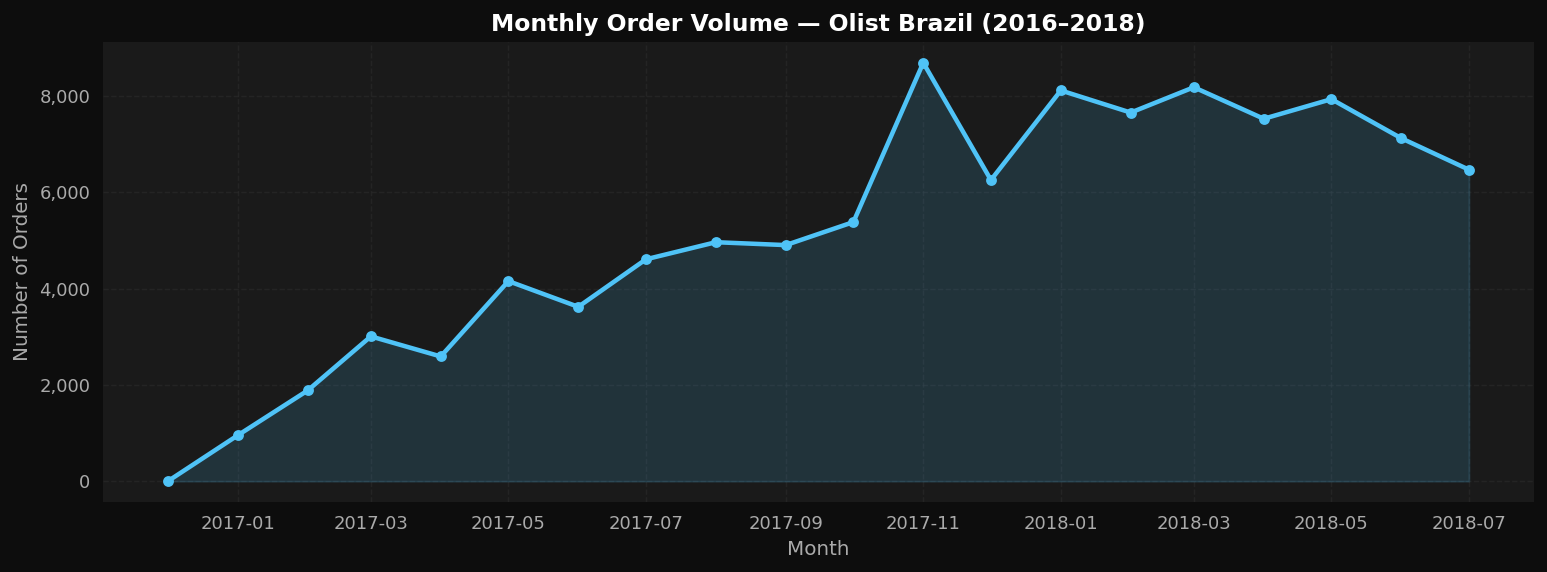

In [27]:
monthly = (
    df1.groupby('purchase_month')
    .agg(order_count=('order_id', 'count'))
    .reset_index()
)
monthly['month_dt'] = monthly['purchase_month'].dt.to_timestamp()
monthly = monthly.iloc[1:-1]

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.fill_between(monthly['month_dt'], monthly['order_count'],
                alpha=0.15, color=COLORS['blue'])
ax.plot(monthly['month_dt'], monthly['order_count'],
        color=COLORS['blue'], lw=2.5, marker='o', ms=5)

peak = monthly.loc[monthly['order_count'].idxmax()]

ax.set_title('Monthly Order Volume — Olist Brazil (2016–2018)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Chart 2 — Delivery Time Distribution
**Chart type:** Histogram + KDE curve
**What it shows:** How long deliveries actually take, including statistical markers.
**SDG 8 link:** Delivery speed directly affects whether e-commerce is a viable economic channel.

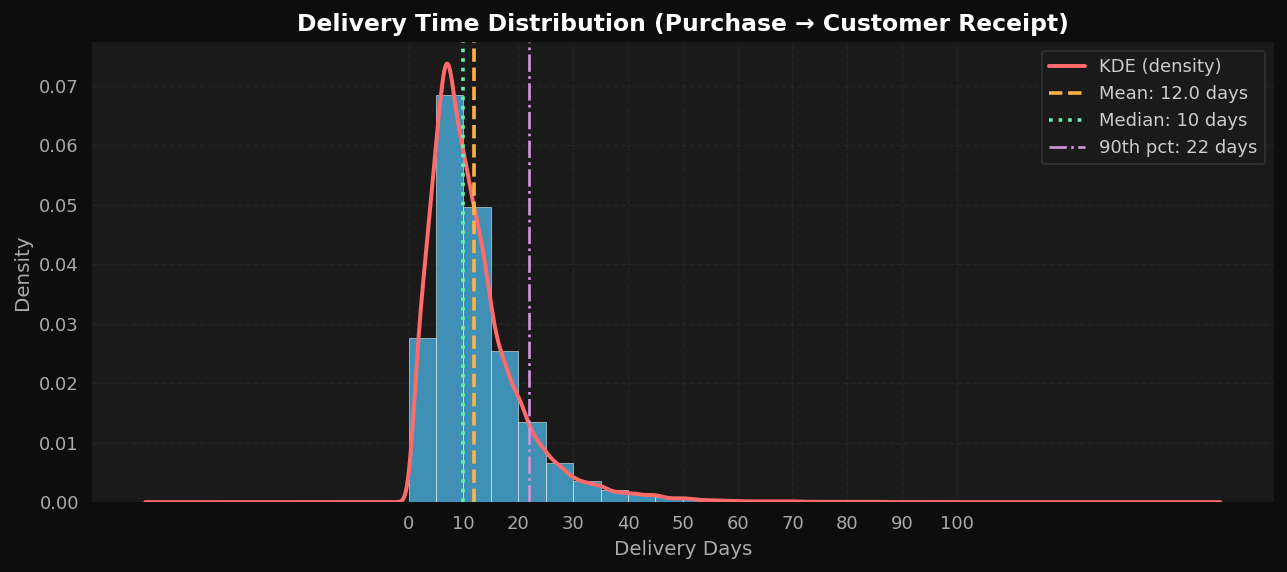

Mean   : 12.0 days
Median : 10 days
90th % : 22 days
Over 30 days: 4,494 orders (4.0%)


In [54]:
delivery_days = df1['delivery_days'].dropna()
delivery_days = delivery_days[(delivery_days > 0) & (delivery_days < 100)]

bin_size = 5

bins = np.arange(0, delivery_days.max() + bin_size, bin_size)

fig, ax = plt.subplots(figsize=(10, 4.5))


ax.hist(delivery_days, bins=bins, color=COLORS['blue'],
        edgecolor='white', linewidth=0.4, alpha=0.7, density=True)

delivery_days.plot.kde(ax=ax, color=COLORS['red'], lw=2.2, label='KDE (density)')

ax.axvline(delivery_days.mean(),
           color=COLORS['orange'], lw=2, linestyle='--',
           label=f'Mean: {delivery_days.mean():.1f} days')

ax.axvline(delivery_days.median(),
           color=COLORS['green'], lw=2, linestyle=':',
           label=f'Median: {delivery_days.median():.0f} days')

ax.axvline(delivery_days.quantile(0.9),
           color=COLORS['purple'], lw=1.5, linestyle='-.',
           label=f'90th pct: {delivery_days.quantile(0.9):.0f} days')

ax.set_xticks(bins)

ax.set_xticks(bins[::2])

ax.set_title('Delivery Time Distribution (Purchase → Customer Receipt)')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Density')

ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Mean   : {delivery_days.mean():.1f} days")
print(f"Median : {delivery_days.median():.0f} days")
print(f"90th % : {delivery_days.quantile(0.9):.0f} days")
print(f"Over 30 days: {(delivery_days > 30).sum():,} orders ({(delivery_days > 30).mean()*100:.1f}%)")

## Chart 3 — Payment Behaviour Analysis
**Chart type:** Pie chart
**What it shows:** Payment method preferences and credit card instalment distribution.
**SDG 8 link:** Instalment patterns reveal financial access and affordability barriers.

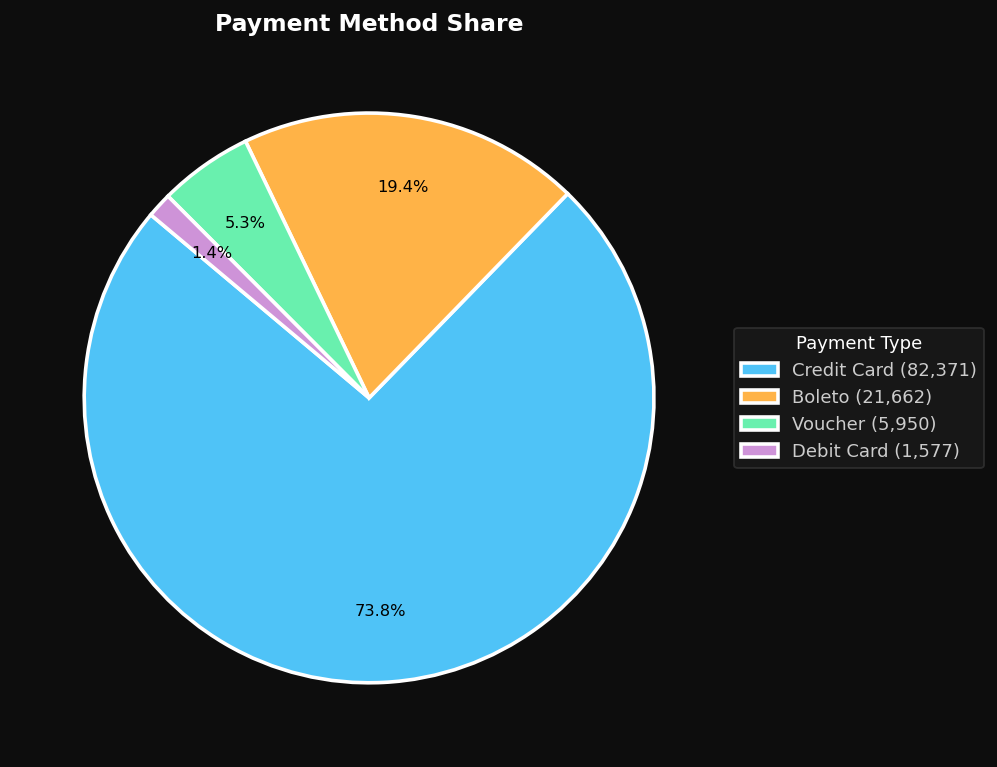

In [63]:
payment_type_counts = df1['payment_type'].astype(str).value_counts()
payment_type_counts.index = payment_type_counts.index.str.replace('_', ' ').str.title()

fig, ax1 = plt.subplots(figsize=(8, 6))

total = payment_type_counts.sum()

def autopct_format(pct):
    count = int(pct * total / 100)
    return f'{pct:.1f}%'   # % + actual value

pie_colors = [COLORS['blue'], COLORS['orange'], COLORS['green'], COLORS['purple'], COLORS['red']]

wedges, texts, autotexts = ax1.pie(
    payment_type_counts.values,
    labels=None,
    autopct=autopct_format,
    colors=pie_colors[:len(payment_type_counts)],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75
)

ax1.legend(
    wedges,
    [f"{label} ({value:,})" for label, value in zip(payment_type_counts.index, payment_type_counts.values)],
    title="Payment Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

for t in autotexts:
    t.set_fontsize(9)
    t.set_color("black")

ax1.set_title('Payment Method Share')
plt.tight_layout()
plt.show()

## Chart 4 — Correlation Matrix
**Chart type:** Heatmap
**What it shows:** Pairwise correlations between all key numerical variables.
**SDG 8 link:** Reveals the drivers of poor customer experience and logistics inefficiency.

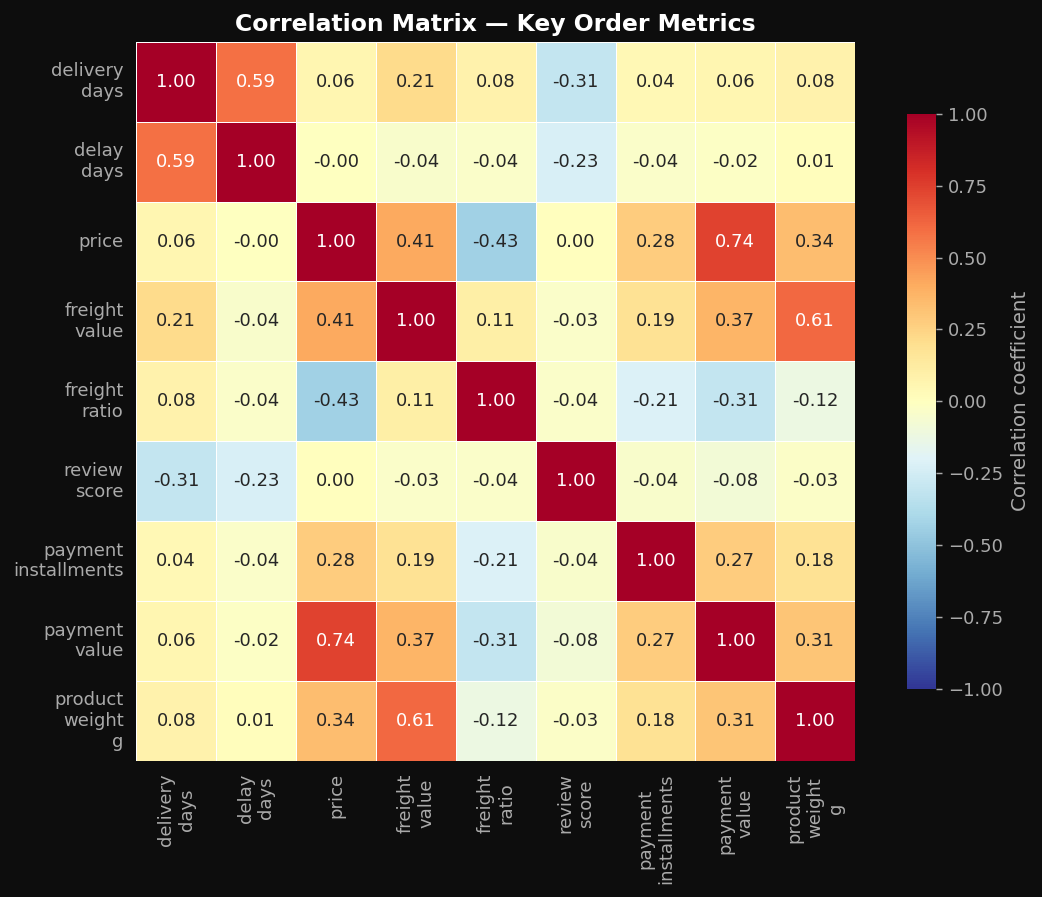

In [43]:
corr_cols = [
    'delivery_days', 'delay_days', 'price',
    'freight_value', 'freight_ratio', 'review_score',
    'payment_installments', 'payment_value', 'product_weight_g'
]

corr_df = df1[corr_cols].copy()
for col in corr_df.columns:
    corr_df[col] = corr_df[col].astype(float)
corr_df = corr_df.dropna()

tick_labels = [c.replace('_', '\n') for c in corr_cols]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_df.corr(), ax=ax,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r', vmin=-1, vmax=1, center=0,
    xticklabels=tick_labels, yticklabels=tick_labels,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'}
)
ax.set_title('Correlation Matrix — Key Order Metrics')
plt.tight_layout()
plt.show()

## Chart 5 — Review Score by Delivery Timeliness
**Chart type:** Box plot
**What it shows:** How customer satisfaction shifts depending on whether an order arrived early or late.
**SDG 8 link:** Links logistics performance directly to customer trust and economic fairness.


Summary:
Early >14d      | n=49,132 | mean=4.22
Early 7-14d     | n=39,417 | mean=4.23
Early 0-7d      | n=15,791 | mean=4.11
Late 1-7d       | n= 4,086 | mean=2.67
Late 8-14d      | n= 1,610 | mean=1.69
Late >14d       | n= 1,524 | mean=1.72


C:\Users\ATIK\AppData\Local\Temp\ipykernel_7380\235445963.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


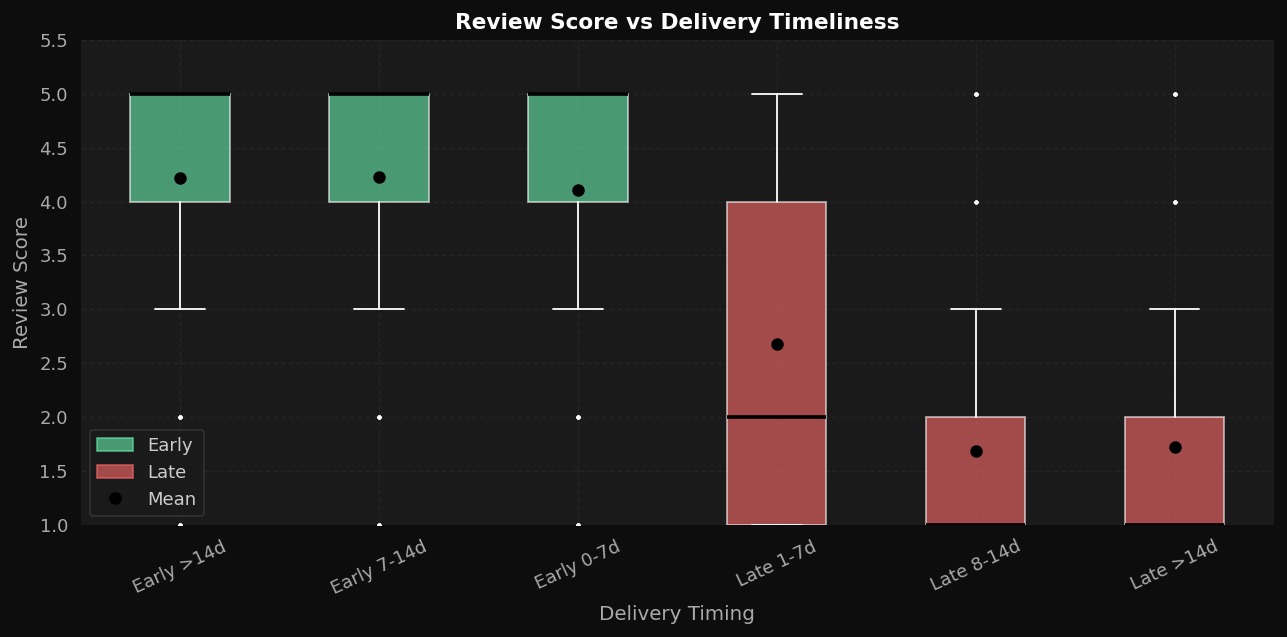

In [64]:
bucket_order = [
    'Early >14d', 'Early 7-14d', 'Early 0-7d',
    'Late 1-7d',  'Late 8-14d',  'Late >14d'
]

plot_df = df1.dropna(subset=['delivery_bucket', 'review_score']).copy()
plot_df['review_score'] = plot_df['review_score'].astype(float)

groups = []
valid_labels = []

for b in bucket_order:
    g = plot_df[plot_df['delivery_bucket'] == b]['review_score'].values
    if len(g) > 0:
        groups.append(g)
        valid_labels.append(b)

print("\nSummary:")
for b, g in zip(valid_labels, groups):
    print(f'{b:15s} | n={len(g):>6,} | mean={g.mean():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    groups,
    labels=valid_labels,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='.', ms=2, alpha=0.25)
)

colors = []
for label in valid_labels:
    if 'Early' in label:
        colors.append(COLORS['green'])
    else:
        colors.append(COLORS['red'])

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

means = [np.mean(g) for g in groups]
ax.scatter(range(1, len(groups)+1), means,
           color='black', s=35, zorder=3, label='Mean')

ax.set_title('Review Score vs Delivery Timeliness', fontsize=12)
ax.set_xlabel('Delivery Timing')
ax.set_ylabel('Review Score')
ax.set_ylim(1, 5.5)

plt.xticks(rotation=25)

ax.legend(handles=[
    mpatches.Patch(color=COLORS['green'], alpha=0.6, label='Early'),
    mpatches.Patch(color=COLORS['red'], alpha=0.6, label='Late'),
    plt.Line2D([0], [0], marker='o', color='black', lw=0, label='Mean')
], framealpha=0.9)

plt.tight_layout()
plt.show()

## Chart 9 — Delivery Performance by State
**Chart type:** Double bar chart (colour-coded by region)
**What it shows:** Average delivery days and late-delivery rate per Brazilian state.
**SDG 8 link:** Exposes geographic inequality in who benefits from e-commerce growth.

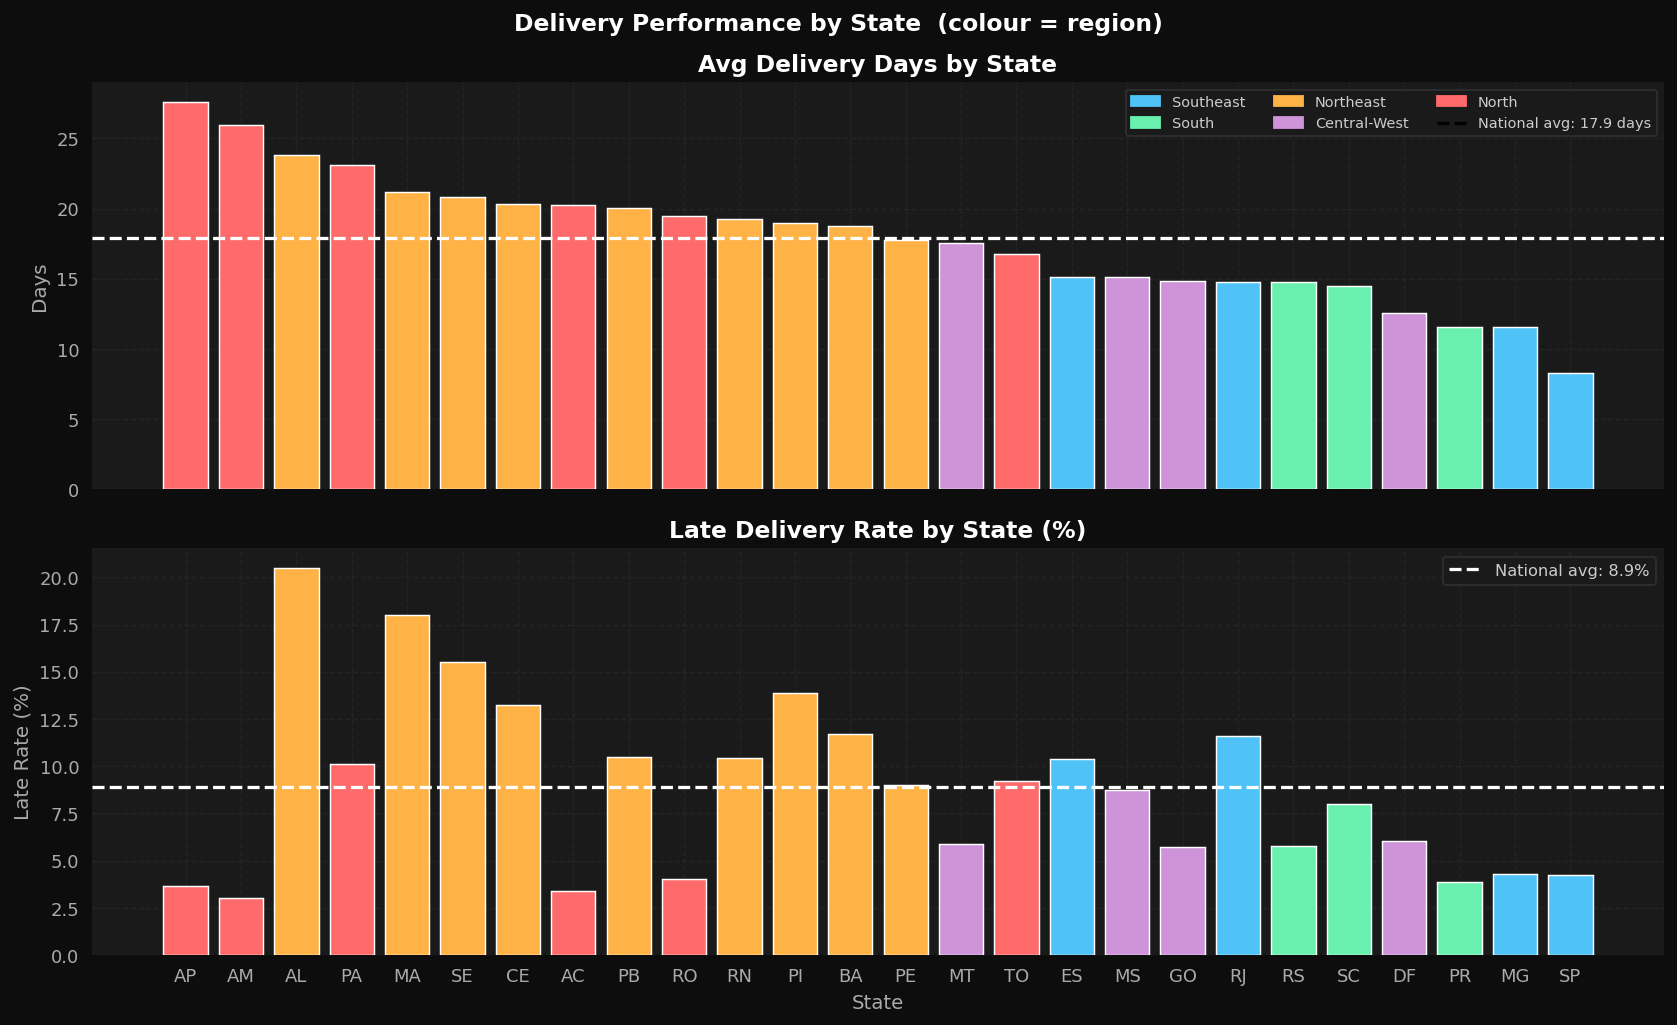

Avg delivery — North: 22.2 days
Avg delivery — Southeast : 12.4 days
Regional gap : 9.7 days


In [65]:
state_perf = (
    df1.groupby('customer_state', observed=True)
    .agg(
        avg_delivery=('delivery_days', 'mean'),
        late_rate=('was_late', 'mean'),
        n=('order_id', 'count')
    )
    .reset_index()
)
state_perf = state_perf[state_perf['n'] >= 50].sort_values('avg_delivery', ascending=False)
state_perf['customer_state'] = state_perf['customer_state'].astype(str).str.upper()
state_perf['region'] = state_perf['customer_state'].map(region_map).fillna('Other')

region_colors = {
    'Southeast': COLORS['blue'],
    'South': COLORS['green'],
    'Northeast': COLORS['orange'],
    'Central-West': COLORS['purple'],
    'North': COLORS['red'],
    'Other': COLORS['gray'],
}
bar_colors = [region_colors.get(r, COLORS['gray']) for r in state_perf['region']]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.bar(state_perf['customer_state'], state_perf['avg_delivery'],
        color=bar_colors, edgecolor='white', linewidth=0.8)
ax1.axhline(state_perf['avg_delivery'].mean(), color='white', lw=1.8, linestyle='--')
ax1.set_title('Avg Delivery Days by State')
ax1.set_ylabel('Days')

ax2.bar(state_perf['customer_state'], state_perf['late_rate'] * 100,
        color=bar_colors, edgecolor='white', linewidth=0.8)
ax2.axhline(state_perf['late_rate'].mean() * 100, color='white', lw=1.8, linestyle='--',
            label=f"National avg: {state_perf['late_rate'].mean()*100:.1f}%")
ax2.set_title('Late Delivery Rate by State (%)')
ax2.set_ylabel('Late Rate (%)')
ax2.set_xlabel('State')
ax2.legend(fontsize=9)

region_legend = [mpatches.Patch(color=c, label=r)
                 for r, c in region_colors.items() if r != 'Other']
ax1.legend(
    handles=region_legend + [plt.Line2D([0], [0], color='black', lw=1.8, linestyle='--',
        label=f"National avg: {state_perf['avg_delivery'].mean():.1f} days")],
    fontsize=8, ncol=3
)

fig.suptitle('Delivery Performance by State  (colour = region)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

north    = state_perf[state_perf['region'] == 'North']['avg_delivery'].mean()
south_e  = state_perf[state_perf['region'] == 'Southeast']['avg_delivery'].mean()
print(f"Avg delivery — North: {north:.1f} days")
print(f"Avg delivery — Southeast : {south_e:.1f} days")
print(f"Regional gap : {north - south_e:.1f} days")